# Flo Energy Take Home Assessment

This notebook cleans the merit order and demand files for January 2023, plots the merit order, and estimates the clearing price from it.

**This notebook**

Each task starts with a summary cell covering the approach, the findings and the deliverable. These 3 cells give the full picture, and the cells below each one show the working.

**Summary**

**Summary**

- **Task 1, clean the data:** both files go through 4 layers (raw, typed, cleansed, staging), with validation in between. Offer Stacks is clean. USEP has 2 bad rows: 1 date is corrected, and 1 row is removed and kept as a gap. 35 price spikes are kept as real prices.
- **Task 2, plot the merit order:** the curve for 2023-01-05 08:00. Most of the capacity is offered below \$0, and the price only climbs steeply in the last few hundred MW.
- **Task 3, clearing price function:** 'calculate_clearing_price()' returns the bid price of the marginal generator, with 7 unit tests. A like for like merit order curve is plotted with the actual USEP and the estimated clearing price. The actual USEP is higher than the estimate in every period, with a median difference of \$7.66/MWh.
- **Bonus, SQL with DuckDB:** the Task 1 cleaning is repeated in SQL in 'bonus_sql_duckdb.ipynb'. 



# Setup

Please run the cell below if you are using Google Collab

In [47]:
import os
import sys

if "google.colab" in sys.modules:
    # Pull the repo, so the file structure is the same as the local one
    if not os.path.exists("/content/flo-energy-data-analytics"):
        !git clone -q https://github.com/xanatower/flo-energy-data-analytics.git /content/flo-energy-data-analytics
    %cd /content/flo-energy-data-analytics

    # Install the packages listed in pyproject.toml into the Colab runtime
    !pip install -q uv
    !uv pip install -q --system -r pyproject.toml --group dev

    %cd analysis

# Task 1



**Summary**

We clean both files through 4 layers. Each layer is kept as its own DataFrame, so every change can be traced back to the source row.

- **Raw:** read the CSVs as they are, and normalise the headers to lower-case snake_case with no unit.
- **Typed:** cast the columns to the data types defined in the schema. Casting failures are flagged, not dropped.
- **Cleansed:** apply only the fixes supported by the validation results. Nothing is imputed.
- **Staging:** rename to ""bid_price"" and ""bid_volume"", and build the ""datetime"" index from ""date"" and ""period"".

Validation runs between the typed and cleansed layers, in 3 levels: structural checks, business checks and anomaly checks.

**Findings and Insights**

- Offer Stacks passed all the checks, so no change is required.

- USEP has 2 bad rows and a number of price spikes:

| Finding | Treatment |
| --- | --- |
| Invalid date 40 Jan 2023 on period 26. The rest of the row is in line with the rows before and after, and 21 Jan is the only day missing period 26. | Date corrected to 21 Jan 2023. |
| Invalid period 99 on 7 Jan, with extreme values in every other column. | Row removed. |
| 7 Jan period 27 is missing, as a result of finding 2. | Kept as a gap, not filled. |
| 35 extreme USEPs, mostly on 9 Jan. The highest is \$4,500/MWh, the same as the highest offer price in the stack, so they look like real price spikes. | Kept. |


- The mean USEP (\$221/MWh) is well above the median (\$177/MWh), as a small number of high prices pull the average up. The highest is \$4,500/MWh.
- Demand is stable in comparison, between 4,936 and 7,045 MW.
- Each period has between 109 and 162 offer tranches, with an offered capacity between 5,837 and 7,728 MW.

**Deliverable**

- "offer_stacks_staging"" and ""usep_staging"", both indexed by ""datetime"" and used in Task 2 and 3.
- ""create_datetime_index()"", where datetime = date + (period - 1) × 30 minutes.


## Ingestion

In [48]:
# Deal with dependency import
from pathlib import Path
import numpy as np
import pandas as pd
import sys


In [49]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [50]:
# specify file locations
RAW_DIR = PROJECT_ROOT / "data" / "raw"
OFFER_STACKS_FILE = RAW_DIR / "DelayedOfferStacks_Energy_01-Jan-2023 to 31-Jan-2023.csv"
USEP_FILE = RAW_DIR / "USEP_Jan-2023.csv"


Inspecting CSVs in file mode over Excel has the advantage of inspecting large CSV dataset that doesn't fit into RAM. 

In [51]:
# Inspect the raw CSVs: first 10 lines of each file, unparsed
for f in (OFFER_STACKS_FILE, USEP_FILE):
    print(f"=== {f.name} ===")
    with open(f, encoding="utf-8-sig") as fh:
        for _, line in zip(range(10), fh):
            print(line.rstrip("\n"))
    print()


=== DelayedOfferStacks_Energy_01-Jan-2023 to 31-Jan-2023.csv ===
Delayed Offer Stacks_Energy,,,
,,,
Date,Period,Lowest to Highest Offer Price ($/MWh),Total Offer Capacity At Specified Offer Price (MW)
01-JAN-2023,1,-4750,84.3
01-JAN-2023,1,-4500,324
01-JAN-2023,1,-90,854
01-JAN-2023,1,-67,200
01-JAN-2023,1,-61,280
01-JAN-2023,1,-60,685
01-JAN-2023,1,-50,20

=== USEP_Jan-2023.csv ===
INFORMATION TYPE,DATE,PERIOD,USEP ($/MWh),LCP ($/MWh),DEMAND (MW),TCL (MW)
USEP,01 Jan 2023,1,158.62,0,5539.761,0
USEP,01 Jan 2023,2,147.58,0,5443.353,0
USEP,01 Jan 2023,3,126.83,0,5384.523,0
USEP,01 Jan 2023,4,144.53,0,5367.272,0
USEP,01 Jan 2023,5,144.51,0,5331.369,0
USEP,01 Jan 2023,6,126.8,0,5289.506,0
USEP,01 Jan 2023,7,108.48,0,5232.943,0
USEP,01 Jan 2023,8,106.74,0,5196.736,0
USEP,01 Jan 2023,9,106.51,0,5173.397,0



[Analysis] Schema

From the specification, inspection of the data above and combining with the business domain knowledge, the table structures are:

Offer Stacks Raw (from 'DelayedOfferStacks_Energy_01-Jan-2023 to 31-Jan-2023.csv'):

| Column                                             | Type  | Descrption                                                                                       |
| -------------------------------------------------- | ----- | ------------------------------------------------------------------------------------------------ |
| Date                                               | date  | Trading date, in format of 'DD-MMM-YYYY'                                                         |
| Period                                             | int   | half hour trading period ID                                                                      |
| Lowest to Highest Offer Price (\$/MWh)              | float | The price at which generation capacity is being offered into the market, sorted from low to high |
| Total Offer Capacity At Specified Offer Price (MW) | float | Total generation capacity offered at that exact price level.                                     |

USEP Raw (from 'USEP_Jan-2023.csv'):

| Column           | Type  | Descrption                                                                      |
| ---------------- | ----- | ------------------------------------------------------------------------------- |
| INFORMATION TYPE | str   | Market information type                                                         |
| DATE             | date  | Trading date, in format of 'DD Mmm YYYY'                                        |
| PERIOD           | int   | Half hour trading period ID                                                     |
| USEP (\$/MWh)     | float | Uniform Singapore Energy Price, the half-hourly wholesale energy price.         |
| LCP (\$/MWh)      | float | Load Curtailment Price.                                                         |
| DEMAND (MW)      | float | System electricity demand for that half-hour, expressed as average power in MW. |
| TCL (MW)         | float | Total Curtailed Load.                                                           |





[Action] Now read the files into pandas df, rename the columns according to spec, and cast the columns into the right data type. 

Rename: According to the spec, all headers need to be normalised to lower-case snake_case formatting with *no unit*

Data type per tables above. 

In [52]:
# The offer stacks file has a title row and a blank row, so the header is on the third row
offer_stacks_raw  = pd.read_csv(OFFER_STACKS_FILE, skiprows=2)
usep_raw = pd.read_csv(USEP_FILE)

# Helper function for header renaming with Regex
def normalise_headers(df: pd.DataFrame) -> pd.DataFrame:
    """Lower-case snake_case headers, e.g. 'DEMAND (MW)' -> 'demand'."""
    df.columns = (
        df.columns.str.replace(r"\(.*?\)", "", regex=True)  # drop units like ($/MWh)
        .str.strip()
        .str.lower()
        .str.replace(r"[^a-z0-9]+", "_", regex=True)
        .str.strip("_")
    ) 
    return df

offer_stacks_raw = normalise_headers(offer_stacks_raw)
usep_raw = normalise_headers(usep_raw)

print("Offer stacks headers:")
print(offer_stacks_raw.columns.tolist())

print("\nUSEP headers:")
print(usep_raw.columns.tolist())



Offer stacks headers:
['date', 'period', 'lowest_to_highest_offer_price', 'total_offer_capacity_at_specified_offer_price']

USEP headers:
['information_type', 'date', 'period', 'usep', 'lcp', 'demand', 'tcl']


[Action] Define schema from information above

The schema design deliberately deliberately captures metadata such as source, table grain, column data types, units and descriptions to support schema traceability and data lineage. 

Due to the time constraint and purpose of this assessment, the traceability feature will not be used through out the data cycle in this assessment. 

The schema change and evolution will be explained and documented in the markdown blocks instead. 


In [53]:
# Define data classes for holding the schema

from dataclasses import dataclass


@dataclass(frozen=True)
class ColumnSpec:
    dtype: str
    description: str
    unit: str | None = None
    nullable: bool = False
    date_format: str | None = None


@dataclass(frozen=True)
class TableSpec:
    sources: tuple[str, ...]
    description: str
    grain: str
    columns: dict[str, ColumnSpec]



In [54]:
OFFER_STACKS_RAW_SPEC = TableSpec(
    sources=("DelayedOfferStacks_Energy_01-Jan-2023 to 31-Jan-2023.csv",),
    description="Generation offer stack for each half-hour trading period.",
    grain="One row per trading period and offer-price tranche.",
    columns={
        "date": ColumnSpec(
            dtype="date",
            description="Trading date.",
            date_format="%d-%b-%Y",
        ),
        "period": ColumnSpec(
            dtype="int",
            description="Half-hour trading period ID.",
        ),
        "lowest_to_highest_offer_price": ColumnSpec(
            dtype="float",
            description="Generation capacity offer price.",
            unit="$/MWh",
        ),
        "total_offer_capacity_at_specified_offer_price": ColumnSpec(
            dtype="float",
            description="Generation capacity offered at the specified price.",
            unit="MW",
        ),
    },
)

USEP_RAW_SPEC = TableSpec(
    sources=("USEP_Jan-2023.csv",),
    description="Half-hourly Singapore electricity market demand and price data.",
    grain="One row per half-hour trading period.",
    columns={
        "information_type": ColumnSpec(
            dtype="str",
            description="Market information type.",
        ),
        "date": ColumnSpec(
            dtype="date",
            description="Trading date.",
            date_format="%d %b %Y",
        ),
        "period": ColumnSpec(
            dtype="int",
            description="Half-hour trading period ID.",
        ),
        "usep": ColumnSpec(
            dtype="float",
            description="Uniform Singapore Energy Price.",
            unit="$/MWh",
        ),
        "lcp": ColumnSpec(
            dtype="float",
            description="Load Curtailment Price.",
            unit="$/MWh",
        ),
        "demand": ColumnSpec(
            dtype="float",
            description="System electricity demand.",
            unit="MW",
        ),
        "tcl": ColumnSpec(
            dtype="float",
            description="Total Curtailed Load.",
            unit="MW",
        ),
    },
)


[Action] 

Writing a generic casting function that retains casting failure for further validation in the validation step

In [55]:
# Generic function for casting column to the right data type defined 
def cast_to_schema(
    df: pd.DataFrame,
    table_spec: TableSpec,
) -> pd.DataFrame:
    """
    Cast columns according to the declared schema.

    Casting failures are retained as row-level metadata so that invalid
    source values can be distinguished from genuinely missing values.
    """
    typed = df.copy()

    missing_columns = set(table_spec.columns) - set(typed.columns)
    if missing_columns:
        raise ValueError(
            f"Missing expected columns: {sorted(missing_columns)}"
        )

    cast_failures: dict[str, pd.Series] = {}

    for column, spec in table_spec.columns.items():
        source = typed[column]

        match spec.dtype:
            case "date":
                casted = pd.to_datetime(
                    source,
                    format=spec.date_format,
                    errors="coerce",
                )

            case "int":
                numeric = pd.to_numeric(
                    source,
                    errors="coerce",
                )

                # Integer columns should not silently accept values such as 1.5.
                valid_integer = numeric.isna() | (numeric % 1 == 0)

                casted = (
                    numeric
                    .where(valid_integer)
                    .astype("Int64")
                )

            case "float":
                casted = pd.to_numeric(
                    source,
                    errors="coerce",
                ).astype("Float64")

            case "str":
                casted = source.astype("string")

            case _:
                raise ValueError(
                    f"Unsupported dtype '{spec.dtype}' "
                    f"for column '{column}'."
                )

        # Only count it as a casting failure when the original source
        # contained a value but the cast result became missing.
        cast_failures[column] = (
            source.notna()
            & casted.isna()
        )

        typed[column] = casted

    failure_frame = pd.DataFrame(cast_failures)

    typed["_cast_failed"] = failure_frame.any(axis=1)

    typed["_cast_failed_columns"] = failure_frame.apply(
        lambda row: ", ".join(row.index[row]),
        axis=1,
    )

    return typed

[Schema]

The following casting activity will introduce 2 new columns in each dataset:

Offer Stacks Typed (from Offer Stacks Raw):

| Column | Type | Description |
|---|---|---|
| Date | date | Trading date, in format of 'DD-MMM-YYYY' |
| Period | int | Half-hour trading period ID |
| Lowest to Highest Offer Price (\$/MWh) | float | The price at which generation capacity is being offered into the market, sorted from low to high |
| Total Offer Capacity At Specified Offer Price (MW) | float | Total generation capacity offered at that exact price level |
| ''_cast_failed'' | bool | Indicates whether one or more populated source values in the row failed type casting |
|''_cast_failed_columns'' | str | Comma-separated list of columns that failed type casting for the row; blank when no casting failure occurred |

USEP Typed (from USEP Raw):

| Column | Type | Description |
|---|---|---|
| INFORMATION TYPE | str | Market information type |
| DATE | date | Trading date, in format of 'DD Mmm YYYY' |
| PERIOD | int | Half-hour trading period ID |
| USEP (\$/MWh) | float | Uniform Singapore Energy Price, the half-hourly wholesale energy price |
| LCP (\$/MWh) | float | Load Curtailment Price |
| DEMAND (MW) | float | System electricity demand for that half-hour, expressed as average power in MW |
| TCL (MW) | float | Total Curtailed Load |
| ''_cast_failed'' | bool | Indicates whether one or more populated source values in the row failed type casting |
| ''_cast_failed_columns'' | str | Comma-separated list of columns that failed type casting for the row; blank when no casting failure occurred |

[Action] 

To keep track of the schema change, we created new schema for both of datasets.

In [56]:
offer_stacks_typed = cast_to_schema(
    offer_stacks_raw,
    OFFER_STACKS_RAW_SPEC,
)

usep_typed = cast_to_schema(
    usep_raw,
    USEP_RAW_SPEC,
)

In [57]:
offer_stacks_typed

,date,period,lowest_to_highest_offer_price,total_offer_capacity_at_specified_offer_price,_cast_failed,_cast_failed_columns
0,2023-01-01,1,-4750.0,84.3,False,
1,2023-01-01,1,-4500.0,324.0,False,
2,2023-01-01,1,-90.0,854.0,False,
3,2023-01-01,1,-67.0,200.0,False,
4,2023-01-01,1,-61.0,280.0,False,
...,...,...,...,...,...,...
206572,2023-01-31,48,3301.0,60.0,False,
206573,2023-01-31,48,3508.0,30.0,False,
206574,2023-01-31,48,3708.0,40.0,False,
206575,2023-01-31,48,4083.2,15.0,False,


In [58]:
usep_typed

,information_type,date,period,usep,lcp,demand,tcl,_cast_failed,_cast_failed_columns
0,USEP,2023-01-01,1,158.62,0.0,5539.761,0.0,False,
1,USEP,2023-01-01,2,147.58,0.0,5443.353,0.0,False,
2,USEP,2023-01-01,3,126.83,0.0,5384.523,0.0,False,
3,USEP,2023-01-01,4,144.53,0.0,5367.272,0.0,False,
4,USEP,2023-01-01,5,144.51,0.0,5331.369,0.0,False,
...,...,...,...,...,...,...,...,...,...
1483,USEP,2023-01-31,44,154.37,0.0,6247.071,0.0,False,
1484,USEP,2023-01-31,45,123.62,0.0,6071.138,0.0,False,
1485,USEP,2023-01-31,46,112.71,0.0,5923.157,0.0,False,
1486,USEP,2023-01-31,47,112.05,0.0,5768.719,0.0,False,


## Validation

[Analysis] 

The following logic will be validating the raw incoming data in different layer:

LAYER 0: data structural check
- cast failure during ingestion
- invalid dates
- null / non-finite values
- period outside 1–48
- missing periods
- duplicate keys

LAYER 1: Business checks

This are dataset specific check to ensure the incoming dataset is compliant to business rules. 

| Dataset      | Column                                                                                                                                                          | Business validation rule                                                                                                                                              |
| ------------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| USEP         | Demand (MW)                                                                                                                                                          | Demand >0 . Assumption: As this is the total system demand of Singapore, this value is expected to be always >0. The validator should raise a warning if Demand  <=0. |
| Offer Stacks | Total Offer Capacity At Specified Offer Price (MW)                                                                                                              | Offer capacity >=0 is defined in Section 5.2.5 is in Chapter 6 (Market Operation) of the Singapore Electricity Market Rules.                                          |
| Offer Stacks | Lowest to Highest Offer Price (\$/MWh)             | The price at which generation capacity is being offered into the market, sorted from low to high | Offer prices have to be non-decreasing per column definition                                                                                                          |


LAYER 2: Anomaly/Outlier checks

This layer uses Interquartile Range to detect outliers, IQR is the spread of the middle 50% of the values (third quartile - first quartile), and any value more than 3 × IQR below Q1 or above Q3 is flagged as an outlier. 


| Dataset      | Column        | Anomaly check |
| ------------ | ------------- | ------------- |
| USEP         | USEP (\$/MWh) | Flag values below Q1 - 3 × IQR or above Q3 + 3 × IQR, where IQR = Q3 - Q1 is the spread of the middle 50% of the values. A multiplier of 3 is used and not the usual 1.5, as electricity prices are spiky by nature. |
| USEP         | Demand (MW)   | Same rule as USEP. |
| Offer Stacks | All columns   | No check defined. An offer stack runs from very low to very high prices by design, so this rule would flag tranches in every period. |



As LAYER 0 is shared by both datasets, we can create an abstract DataValidator parent class, and reuse the layer 0 code in the children classes that belong to each dataset individually. 

[Action] To keep track of the schema change, we created new schema for both of datasets.

In [59]:
from abc import ABC, abstractmethod
from typing import ClassVar

class DataValidator(ABC):
    """Base validator containing common structural data-quality checks."""

    # TODO: move these to __init__
    EXPECTED_PERIODS: ClassVar[range] = range(1, 49)
    EXPECTED_START_DATE: ClassVar[str] = "2023-01-01"
    EXPECTED_END_DATE: ClassVar[str] = "2023-01-31"

    KEY_COLUMNS: ClassVar[list[str]]

    def __init__(
        self,
        raw: pd.DataFrame,
        typed: pd.DataFrame,
        table_spec: TableSpec,
    ) -> None:
        self.raw = raw
        self.typed = typed
        self.table_spec = table_spec

    
    def cast_failures(self) -> pd.DataFrame:
        """Return source rows containing one or more casting failures."""
        mask = self.typed["_cast_failed"]

        if not mask.any():
            return pd.DataFrame()

        result = self.raw.loc[mask].copy()

        result.insert(
            0,
            "cast_failed_columns",
            self.typed.loc[mask, "_cast_failed_columns"],
        )

        return result

    def required_nulls(self) -> pd.DataFrame:
        """Return null values from non-nullable source columns."""
        issues = []

        for column, spec in self.table_spec.columns.items():
            if spec.nullable:
                continue

            mask = self.raw[column].isna()

            if mask.any():
                issues.append(
                    pd.DataFrame(
                        {
                            "row": self.raw.index[mask],
                            "column": column,
                        }
                    )
                )

        if not issues:
            return pd.DataFrame(
                columns=["row", "column"]
            )

        return pd.concat(issues, ignore_index=True)

    def non_finite_values(self) -> pd.DataFrame:
        """Return +/- infinity from numeric columns."""
        issues = []

        for column, spec in self.table_spec.columns.items():
            if spec.dtype not in {"int", "float"}:
                continue

            values = self.typed[column].to_numpy(
                dtype=float,
                na_value=np.nan,
            )

            mask = (
                ~np.isnan(values)
                & ~np.isfinite(values)
            )

            if mask.any():
                issues.append(
                    pd.DataFrame(
                        {
                            "row": self.typed.index[mask],
                            "column": column,
                            "value": self.typed.loc[
                                mask,
                                column,
                            ].values,
                        }
                    )
                )

        if not issues:
            return pd.DataFrame(
                columns=["row", "column", "value"]
            )

        return pd.concat(issues, ignore_index=True)


    def invalid_periods(self) -> pd.DataFrame:
        """Return periods outside the expected half-hour range."""
        mask = (
            self.typed["period"].notna()
            & ~self.typed["period"].isin(
                self.EXPECTED_PERIODS
            )
        )

        return self.typed.loc[
            mask,
            ["date", "period"],
        ].copy()

    def missing_periods(self) -> pd.DataFrame:
        """Return expected date/period combinations not present in the data."""
        expected = pd.MultiIndex.from_product(
            [
                pd.date_range(
                    self.EXPECTED_START_DATE,
                    self.EXPECTED_END_DATE,
                    freq="D",
                ),
                self.EXPECTED_PERIODS,
            ],
            names=["date", "period"],
        )

        actual = (
            self.typed.loc[
                self.typed["date"].notna()
                & self.typed["period"].isin(
                    self.EXPECTED_PERIODS
                ),
                ["date", "period"],
            ]
            .drop_duplicates()
            .copy()
        )

        actual["date"] = actual["date"].dt.normalize()
        actual["period"] = actual["period"].astype(int)

        actual_index = pd.MultiIndex.from_frame(actual)

        return (
            expected
            .difference(actual_index)
            .to_frame(index=False)
        )

    def duplicate_keys(self) -> pd.DataFrame:
        """Return duplicated rows at the expected table grain."""
        valid_keys = (
            self.typed[self.KEY_COLUMNS]
            .notna()
            .all(axis=1)
        )

        duplicate = (
            valid_keys
            & self.typed.duplicated(
                self.KEY_COLUMNS,
                keep=False,
            )
        )

        return (
            self.typed.loc[duplicate]
            .sort_values(self.KEY_COLUMNS)
            .copy()
        )

    def layer_0(self) -> dict[str, pd.DataFrame]:
        """Structural validation."""
        return {
            "cast_failures": self.cast_failures(),
            "required_nulls": self.required_nulls(),
            "non_finite_values": self.non_finite_values(),
            "invalid_periods": self.invalid_periods(),
            "missing_periods": self.missing_periods(),
            "duplicate_keys": self.duplicate_keys(),
        }

    @abstractmethod
    def layer_1(self) -> dict[str, pd.DataFrame]:
        """Business-rule validation."""
        ...

    @abstractmethod
    def layer_2(self) -> dict[str, pd.DataFrame]:
        """Anomaly checks for investigation."""
        ...

    def validate(
        self,
    ) -> dict[str, dict[str, pd.DataFrame]]:
        """Run all validation layers."""
        return {
            "layer_0_structural": self.layer_0(),
            "layer_1_business": self.layer_1(),
            "layer_2_anomaly": self.layer_2(),
        }

    def print_validation_results(
        self,
        show_details: bool = True,
        max_rows: int = 10,
    ) -> None:
        """Run validation and display a readable validation report."""
        results = self.validate()

        layer_labels = {
            "layer_0_structural": "LAYER 0 - Structural Checks",
            "layer_1_business": "LAYER 1 - Business Checks",
            "layer_2_anomaly": "LAYER 2 - Anomaly Checks",
        }

        for layer, checks in results.items():
            print(f"\n{layer_labels[layer]}")
            print("-" * len(layer_labels[layer]))

            if not checks:
                print("No checks defined.")
                continue

            for check_name, issues in checks.items():
                readable_name = check_name.replace("_", " ").title()
                issue_count = len(issues)

                if issue_count == 0:
                    status = "PASS"
                elif layer == "layer_2_anomaly":
                    status = "REVIEW"
                else:
                    status = "FAIL"

                print(
                    f"{status:<6} | "
                    f"{readable_name:<35} | "
                    f"{issue_count} issue(s)"
                )

                if (
                    show_details
                    and issue_count > 0
                ):
                    print(
                        issues.head(max_rows).to_string(
                            index=False
                        )
                    )

                    if issue_count > max_rows:
                        print(
                            f"... {issue_count - max_rows} "
                            "additional row(s) not shown"
                        )

                    print()

[Action]

Build the validator for Offer Stack

In [60]:
class OfferStackValidator(DataValidator):
    """Validation rules specific to the offer stack dataset."""

    OFFER_PRICE_COLUMN = "lowest_to_highest_offer_price"
    OFFER_CAPACITY_COLUMN = "total_offer_capacity_at_specified_offer_price"

    KEY_COLUMNS = [
        "date",
        "period",
        OFFER_PRICE_COLUMN,
    ]

    def layer_1(self) -> dict[str, pd.DataFrame]:
        """Business-rule validation."""
        return {
            "negative_offer_capacity":
                self._negative_offer_capacity(),

            "non_monotonic_offer_price":
                self._non_monotonic_offer_price(),
        }

    def layer_2(self) -> dict[str, pd.DataFrame]:
        """Anomaly checks for investigation."""
        return {}

    def _negative_offer_capacity(self) -> pd.DataFrame:
        """Find offer capacities below zero."""
        mask = (
            self.typed[self.OFFER_CAPACITY_COLUMN] < 0
        )

        return self.typed.loc[
            mask,
            [
                "date",
                "period",
                self.OFFER_PRICE_COLUMN,
                self.OFFER_CAPACITY_COLUMN,
            ],
        ].copy()

    def _non_monotonic_offer_price(self) -> pd.DataFrame:
        """
        Find offer prices that decrease within a trading period.

        The source offer stack is expected to be ordered from the
        lowest to highest offer price within each date/period.
        """
        prices = self.typed[
            [
                "date",
                "period",
                self.OFFER_PRICE_COLUMN,
            ]
        ].copy()

        prices["previous_offer_price"] = (
            prices
            .groupby(
                ["date", "period"],
                sort=False,
            )[self.OFFER_PRICE_COLUMN]
            .shift()
        )

        mask = (
            prices[self.OFFER_PRICE_COLUMN]
            < prices["previous_offer_price"]
        )

        return prices.loc[mask].copy()

[Action]

Building validator for USEP

In [61]:
class USEPValidator(DataValidator):
    """Validation rules specific to the USEP dataset."""

    KEY_COLUMNS = [
        "date",
        "period",
    ]

    def layer_1(self) -> dict[str, pd.DataFrame]:
        """Business-rule validation."""
        return {
            "negative_demand":
                self._negative_demand(),
        }

    def layer_2(self) -> dict[str, pd.DataFrame]:
        """Anomaly checks for investigation."""
        return {
            "extreme_usep":
                self._extreme_values("usep"),

            "extreme_demand":
                self._extreme_values("demand"),
        }

    def _negative_demand(self) -> pd.DataFrame:
        mask = self.typed["demand"] <= 0

        return self.typed.loc[
            mask,
            [
                "date",
                "period",
                "demand",
            ],
        ].copy()

    def _extreme_values(
        self,
        column: str,
        iqr_multiplier: float = 3.0,
    ) -> pd.DataFrame:
        values = self.typed[column].dropna()

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower = q1 - iqr_multiplier * iqr
        upper = q3 + iqr_multiplier * iqr

        mask = (
            (self.typed[column] < lower)
            | (self.typed[column] > upper)
        )

        result = self.typed.loc[
            mask,
            [
                "date",
                "period",
                column,
            ],
        ].copy()

        result["lower_bound"] = lower
        result["upper_bound"] = upper

        return result

In [62]:
offer_validator = OfferStackValidator(
    raw=offer_stacks_raw,
    typed=offer_stacks_typed,
    table_spec=OFFER_STACKS_RAW_SPEC,
)

usep_validator = USEPValidator(
    raw=usep_raw,
    typed=usep_typed,
    table_spec=USEP_RAW_SPEC,
)

offer_validation = offer_validator.validate()
usep_validation = usep_validator.validate()



In [63]:
offer_validator.print_validation_results()


LAYER 0 - Structural Checks
---------------------------
PASS   | Cast Failures                       | 0 issue(s)
PASS   | Required Nulls                      | 0 issue(s)
PASS   | Non Finite Values                   | 0 issue(s)
PASS   | Invalid Periods                     | 0 issue(s)
PASS   | Missing Periods                     | 0 issue(s)
PASS   | Duplicate Keys                      | 0 issue(s)

LAYER 1 - Business Checks
-------------------------
PASS   | Negative Offer Capacity             | 0 issue(s)
PASS   | Non Monotonic Offer Price           | 0 issue(s)

LAYER 2 - Anomaly Checks
------------------------
No checks defined.


In [64]:
usep_validator.print_validation_results()


LAYER 0 - Structural Checks
---------------------------
FAIL   | Cast Failures                       | 1 issue(s)
cast_failed_columns information_type        date  period   usep  lcp   demand  tcl
               date             USEP 40 Jan 2023      26 112.12  0.0 5793.256  0.0

PASS   | Required Nulls                      | 0 issue(s)
PASS   | Non Finite Values                   | 0 issue(s)
FAIL   | Invalid Periods                     | 1 issue(s)
      date  period
2023-01-07      99

FAIL   | Missing Periods                     | 2 issue(s)
      date  period
2023-01-07      27
2023-01-21      26

PASS   | Duplicate Keys                      | 0 issue(s)

LAYER 1 - Business Checks
-------------------------
PASS   | Negative Demand                     | 0 issue(s)

LAYER 2 - Anomaly Checks
------------------------
REVIEW | Extreme Usep                        | 36 issue(s)
      date  period     usep  lower_bound  upper_bound
2023-01-06      40   799.79      -292.67       659.26
20

[Analysis]

Deep dive into the findings. 

### Finding 1: Cast failure




In [65]:
# Cast failures: find where each failed row belongs, using chronological

# neighbours by (date, period) rather than file position
PERIODS = range(1, 49)

cast_failures = usep_validation["layer_0_structural"]["cast_failures"]

d = usep_raw.assign(
    date_parsed=pd.to_datetime(usep_raw["date"], format="%d %b %Y", errors="coerce"),
    period_num=pd.to_numeric(usep_raw["period"], errors="coerce"),
)

# Every (date, period) slot that has no valid row
valid = d[d["date_parsed"].notna() & d["period_num"].isin(PERIODS)]
all_slots = pd.MultiIndex.from_product(
    [pd.date_range(valid["date_parsed"].min(), valid["date_parsed"].max()), PERIODS],
    names=["date_parsed", "period_num"],
)
missing_slots = all_slots.difference(
    pd.MultiIndex.from_frame(valid[["date_parsed", "period_num"]])
).to_frame(index=False)

for idx in cast_failures.index.unique():
    row = d.loc[idx]
    print(f"=== Cast failure at source row {idx}: date '{row['date']}', period {row['period']} ===")

    # Candidate slots: empty slots with the same period as the failed row
    candidates = missing_slots[missing_slots["period_num"] == row["period_num"]]
    print(f"Empty slots for period {row['period']}: {len(candidates)}")

    for cand_date in candidates["date_parsed"]:
        neighbours = valid[
            (valid["date_parsed"] == cand_date)
            & valid["period_num"].between(row["period_num"] - 3, row["period_num"] + 3)
        ]
        window = (
            pd.concat([neighbours, d.loc[[idx]].assign(date_parsed=cand_date)])
            .sort_values("period_num")
        )
        print(f"\nCandidate {cand_date:%d %b %Y}, chronological neighbours (failed row inserted):")
        display(window[["date", "period", "usep", "lcp", "demand", "tcl"]])

=== Cast failure at source row 985: date '40 Jan 2023', period 26 ===
Empty slots for period 26: 1

Candidate 21 Jan 2023, chronological neighbours (failed row inserted):


,date,period,usep,lcp,demand,tcl
982,21 Jan 2023,23,116.85,0.0,5865.057,0.0
983,21 Jan 2023,24,112.15,0.0,5802.246,0.0
984,21 Jan 2023,25,111.55,0.0,5755.961,0.0
985,40 Jan 2023,26,112.12,0.0,5793.256,0.0
986,21 Jan 2023,27,112.16,0.0,5832.330,0.0
987,21 Jan 2023,28,123.88,0.0,5887.149,0.0
988,21 Jan 2023,29,124.77,0.0,5906.214,0.0


**Diagnosis**

The casting failed due to the date of 40-Jan. from inspection and the abnormality report, this row is most likely valid due to the rest of the columns have data that is in then similar magnitude to the rows before and after. 

The only invalid item is the date. 

**Treatment**

Manually replace the date to 21 Jan 2023 




### Finding 2: Invalid period & Anomaly Checks

In [66]:
# Invalid periods
invalid_periods = usep_validation[
    "layer_0_structural"
]["invalid_periods"]

for idx in invalid_periods.index:
    pos = usep_raw.index.get_loc(idx)

    print(f"Invalid period at source row {idx}")
    display(
        usep_raw.iloc[
            max(0, pos - 10):
            min(len(usep_raw), pos + 11)
        ]
    )

Invalid period at source row 314


,information_type,date,period,usep,lcp,demand,tcl
304,USEP,07 Jan 2023,17,250.62,0.00,5999.232,0.000
305,USEP,07 Jan 2023,18,250.65,0.00,6080.676,0.000
306,USEP,07 Jan 2023,19,251.30,0.00,6152.582,0.000
307,USEP,07 Jan 2023,20,251.30,0.00,6205.786,0.000
308,USEP,07 Jan 2023,21,251.29,0.00,6235.094,0.000
309,USEP,07 Jan 2023,22,251.29,0.00,6282.264,0.000
310,USEP,07 Jan 2023,23,250.59,0.00,6265.003,0.000
311,USEP,07 Jan 2023,24,246.26,0.00,6227.266,0.000
312,USEP,07 Jan 2023,25,207.58,0.00,6155.603,0.000
313,USEP,07 Jan 2023,26,216.70,0.00,6162.875,0.000


**Diagnosis**

Row 315 of usep_raw seems to be an outlier. Not only is the period ID is invalid, the values from other columns has also been identified as abnormal in extreme 'demand' and 'usep'. 


**Treatment**

As this is a complete outlier that doesn't fit into the nearby rows, it's better to consider this row of data invalid. 


### Finding 3: Missing Periods

**Diagnosis**

From then report, the two missing periods are:

21 Jan 2023, period 26, which we have addressed in Issue 1

07 Jan 2023, period 27, which we have addressed in Issue 2

Finding 4: Extreme USEPs

**Diagnosis**

By visual inspection, the anomaly check flagged 36 extreme USEPs. One of them is the invalid period 99 row from Issue 2. The other 35 look like real price spikes, not bad data:

- They passed all the structural and business checks.
- They are clustered. 29 of the 35 are one continuous run on 9 Jan, from period 16 to 44 (07:30 to 22:00), which is not what a one-off data error looks like.
- The highest USEP is \$4,500/MWh, the same as the highest offer price in the offer stack.
- Supply was tight in these periods. 

**Treatment**

No action. The spikes are kept as they are, since being a statistical outlier alone doesn't make a price invalid.

Issue Summary

| # | Issue | Affected row(s) | Diagnosis | Treatment |
|---|-------|-----------------|-----------|-----------|
| 1 | Cast failure | `usep_raw`, date `40 Jan 2023` (period 26) | Date can't be parsed. All other columns are in line with the neighbouring rows, so the row itself looks valid and only the date is wrong. | Correct the date to `21 Jan 2023`. |
| 2 | Invalid period & anomaly | `usep_raw`, row 315 | Invalid period ID, with extreme `demand` and `usep` values that don't fit the neighbouring rows. | Treat the row as invalid and remove it. |
| 3 | Missing periods | `21 Jan 2023` period 26, `07 Jan 2023` period 27 | Both gaps come from the issues above: Issue 1 (21 Jan, period 26) and Issue 2 (07 Jan, period 27). | 21 Jan period 26 is restored by the Issue 1 fix. 07 Jan period 27 stays missing, and the gap is documented rather than filled. |
| 4 | Extreme USEPs | 35 rows, 29 of them on 9 Jan | Real price spikes during tight supply, in line with the offer stack. | No action, kept. |



### Cleansing

[Schema]

Schema summary for this stage:

Offer Stacks Cleansed (from Offer Stacks Typed):

| Column                                             | Type  | Descrption                                                                                       |
| -------------------------------------------------- | ----- | ------------------------------------------------------------------------------------------------ |
| Date                                               | date  | Trading date, in format of 'DD-MMM-YYYY'                                                         |
| Period                                             | int   | half hour trading period ID                                                                      |
| Lowest to Highest Offer Price ($/MWh)              | float | The price at which generation capacity is being offered into the market, sorted from low to high |
| Total Offer Capacity At Specified Offer Price (MW) | float | Total generation capacity offered at that exact price level.                                     |

USEP Cleansed (from USEP Typed):

| Column           | Type  | Descrption                                                                      |
| ---------------- | ----- | ------------------------------------------------------------------------------- |
| INFORMATION TYPE | str   | Market information type                                                         |
| DATE             | date  | Trading date, in format of 'DD Mmm YYYY'                                        |
| PERIOD           | int   | Half hour trading period ID                                                     |
| USEP (\$/MWh)     | float | Uniform Singapore Energy Price, the half-hourly wholesale energy price.         |
| LCP (\$/MWh)      | float | Load Curtailment Price.                                                         |
| DEMAND (MW)      | float | System electricity demand for that half-hour, expressed as average power in MW. |
| TCL (MW)         | float | Total Curtailed Load.                                                           |



[Action] To keep track of the schema change, we created new schema for both of datasets.

In [67]:
# --- Cleanse USEP ---------------------------------------------------

usep_cleansed = usep_typed.copy()

# Correct the malformed date identified during validation.
# The source row "40 Jan 2023", period 26 aligns with the otherwise
# missing 21 Jan 2023, period 26 interval.
date_correction_mask = (
    usep_raw["date"].eq("40 Jan 2023")
    & usep_raw["period"].eq(26)
)

assert date_correction_mask.sum() == 1

usep_cleansed.loc[
    date_correction_mask,
    "date",
] = pd.Timestamp("2023-01-21")


# Remove structurally invalid period 99.
# The row also contains anomalous values, so it is treated as corrupted
# rather than relabelled as the missing period 27.
invalid_period_mask = ~usep_cleansed["period"].isin(
    DataValidator.EXPECTED_PERIODS
)

usep_cleansed = usep_cleansed.loc[
    ~invalid_period_mask
].copy()


# Remove temporary casting metadata.
usep_cleansed = usep_cleansed.drop(
    columns=[
        "_cast_failed",
        "_cast_failed_columns",
    ]
)

# Restore chronological ordering.
usep_cleansed = usep_cleansed.sort_values(
    ["date", "period"]
)

In [68]:
# --- Cleanse offer stacks -------------------------------------------

offer_stacks_cleansed = offer_stacks_typed.copy()

# No source records required correction or removal based on the
# structural and business-rule validation performed above.

offer_stacks_cleansed = offer_stacks_cleansed.drop(
    columns=[
        "_cast_failed",
        "_cast_failed_columns",
    ]
)

offer_stacks_cleansed = offer_stacks_cleansed.sort_values(
    [
        "date",
        "period",
        "lowest_to_highest_offer_price",
    ]
)

## Staging

The staging layer contains the standardised, analytics-ready representation of each dataset.

At this stage:

- column names are standardised to concise lowercase names;
- the Offer Stacks price and capacity fields are renamed to `bid_price` and `bid_volume`;
- a `datetime` value is derived from `date` and `period`;
- `datetime` is set as the DataFrame index;
- the original `date` and `period` columns are retained for traceability and easier interpretation.

The trading timestamp is calculated as:

`datetime = date + (period - 1) × 30 minutes`

Therefore, Period 1 corresponds to 00:00, Period 2 to 00:30, and so on.

[Schema]

#### Offer Stacks Staging
Source: `offer_stacks_cleansed`

**Index**

| Field | Type | Description |
| --- | --- | --- |
| `datetime` | datetime | Start timestamp of the half-hour trading period, derived from `date` and `period`. |

**Columns**

| Column | Type | Unit | Description |
| --- | --- | --- | --- |
| `date` | date |  | Trading date. |
| `period` | int |  | Half-hour trading period ID, from 1 to 48. |
| `bid_price` | float | $/MWh | Price at which generation capacity is offered into the market. |
| `bid_volume` | float | MW | Total generation capacity offered at the specified bid price. |

Column mapping from the cleansed layer:

| Cleansed column | Staging column |
| --- | --- |
| `lowest_to_highest_offer_price` | `bid_price` |
| `total_offer_capacity_at_specified_offer_price` | `bid_volume` |

#### USEP Staging
Source: `usep_cleansed`

**Index**

| Field | Type | Description |
| --- | --- | --- |
| `datetime` | datetime | Start timestamp of the half-hour trading period, derived from `date` and `period`. |

**Columns**

| Column | Type | Unit | Description |
| --- | --- | --- | --- |
| `information_type` | str |  | Market information type. |
| `date` | date |  | Trading date. |
| `period` | int |  | Half-hour trading period ID, from 1 to 48. |
| `usep` | float | \$/MWh | Uniform Singapore Energy Price for the half-hour trading period. |
| `lcp` | float | \$/MWh | Load Curtailment Price. |
| `demand` | float | MW | System electricity demand for the half-hour trading period. |
| `tcl` | float | MW | Total Curtailed Load. |

In [69]:
# Helper function for building the datetime index from dataframe that has ['date', 'period'] columns

def create_datetime_index(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Create the half-hour trading datetime from date and period,
    then use it as the DataFrame index.

    Period 1 starts at 00:00, Period 2 at 00:30, etc.
    """
    staged = df.copy()

    staged["datetime"] = (
        staged["date"]
        + pd.to_timedelta(
            (staged["period"] - 1) * 30,
            unit="min",
        )
    )

    return (
        staged
        .set_index("datetime")
        .sort_index()
    )

In [70]:
BID_PRICE = "bid_price"
BID_VOLUME = "bid_volume"

# -------------------------------------------------------------------
# Offer stacks staging layer
# -------------------------------------------------------------------

offer_stacks_staging = offer_stacks_cleansed.rename(
    columns={
        "lowest_to_highest_offer_price": BID_PRICE,
        "total_offer_capacity_at_specified_offer_price": BID_VOLUME,
    }
).copy()

offer_stacks_staging = create_datetime_index(
    offer_stacks_staging
)

# -------------------------------------------------------------------
# USEP staging layer
# -------------------------------------------------------------------

usep_staging = create_datetime_index(
    usep_cleansed
)

[Further Analysis]

A quick summary of the 2 staging tables before we use them in Task 2 and 3.

In [71]:
# USEP staging: one row per trading period
display(
    usep_staging[["usep", "demand"]]
    .agg(["count", "min", "median", "mean", "max"])
    .round(1)
)

# Offer stacks staging: summarised to one row per trading period
offer_stacks_by_period = (
    offer_stacks_staging
    .groupby(level="datetime")
    .agg(
        tranches=("bid_price", "size"),
        lowest_bid_price=("bid_price", "min"),
        highest_bid_price=("bid_price", "max"),
        offered_capacity=("bid_volume", "sum"),
    )
)

display(
    offer_stacks_by_period
    .agg(["count", "min", "median", "max"])
    .round(1)
)

,usep,demand
count,1487.0,1487.0
min,76.2,4936.4
median,177.1,6019.7
mean,221.0,6055.3
max,4500.0,7044.9


,tranches,lowest_bid_price,highest_bid_price,offered_capacity
count,1488.0,1488.0,1488.0,1488.0
min,109.0,-4750.0,3699.2,5837.1
median,141.0,-4750.0,4103.2,6884.2
max,162.0,-4750.0,4500.0,7727.6


[Insights] Insights for the quick statistics

- USEP has 1,487 periods and Offer Stacks has 1,488, as the 7 Jan period 27 gap only exists in USEP.
- The mean USEP (\$221/MWh) is well above the median (\$177/MWh), so a small number of high prices pull the average up. The highest is \$4,500/MWh.
- Demand is stable in comparison, between 4,936 and 7,045 MW.
- Each period has between 109 and 162 offer tranches, and every period starts at the same lowest offer of -\$4,750/MWh.
- The offered capacity is between 5,837 and 7,728 MW per period, so at its lowest it is below the highest demand of the month (7,045 MW).

# Task 2 

**Summary**

We build the merit order from the staging tables in the following steps:

- **Modelled:** add `cumulative_bid_volume` to the offer stacks, as the running total of `bid_volume` within each trading period. Keep only `demand` and `usep` from USEP.
- **Merit order:** left join the two on `datetime`, so `demand` and `usep` are repeated on every tranche of the period.
- **Merit order cleansed:** remove the period that has no `demand` and `usep`.
- **Plot:** filter to the chosen period and plot `bid_price` against `cumulative_bid_volume`.


**Finding and Insights**

- 7 Jan period 27 has an offer stack but no demand or USEP, as a result of the gap from Task 1. It is removed from the merit order. 
- The curve has the same shape as the example. 
- for the trading peroid analysed, most of the capacity is offered below \$0: 4,461 MW out of 6,982 MW. The price only climbs steeply in the last few hundred MW.

From analysing merit_order further

- About two thirds of the offered capacity is priced below \$0 in every period, between 60% and 75%. This is the long flat part of the merit order curve.
- The spare capacity, which is the offered capacity left after meeting demand, is 844 MW in a typical period and as low as 94 MW.
- All 35 extreme USEPs were in periods with 420 MW of spare capacity or less, with a median of 255 MW against 850 MW for the other periods.


**Deliverable**
- The merit order plot for 2023-01-05 08:00.
- `merit_order_cleansed`, used in Task 3.
- `add_cumulative_bid_volume()`, `filter_merit_order()` and `plot_merit_order()`.


**Note:** the plot here shows the merit order curve only. The like for like version of the example, with the demand, the estimated clearing price and the actual USEP marked on the curve, is in Task 3, as it needs the clearing price function built there.


[Schema]

We will be building  a new modelled layer for both Offer Stacks and USEP for this task. 

The schema and origin of these datasets are shown below:
### Offer Stacks Modelled

Source: `offer_stacks_staging`

Grain: One row per trading period and bid-price tranche.


**Index**

| Field | Type | Description |
| --- | --- | --- |
| `datetime` | datetime | Start timestamp of the half-hour trading period. |

**Columns**

| Column | Type | Unit | Description |
| --- | --- | --- | --- |
| `date` | date |  | Trading date. |
| `period` | int |  | Half-hour trading period ID, from 1 to 48. |
| `bid_price` | float | \$/MWh | Price at which generation capacity is offered into the market. |
| `bid_volume` | float | MW | Generation capacity offered at the specified bid price. |
| `cumulative_bid_volume` | float | MW | Running total of offered generation capacity within the trading period, ordered by `bid_price`. |

### USEP Modelled

Source: `usep_staging`

Grain: One row per half-hour trading period.



**Index**

| Field | Type | Description |
| --- | --- | --- |
| `datetime` | datetime | Start timestamp of the half-hour trading period. |

**Columns**

| Column | Type | Unit | Description |
| --- | --- | --- | --- |
| `date` | date |  | Trading date. |
| `period` | int |  | Half-hour trading period ID, from 1 to 48. |
| `demand` | float | MW | System electricity demand for the half-hour trading period. |
| `usep` | float | \$/MWh | Published Uniform Singapore Energy Price for the half-hour trading period. |

[Action]

Helper function to add the cumulative bid column, calculated from the bid_volume column

In [72]:
def add_cumulative_bid_volume(
    df: pd.DataFrame,
) -> pd.DataFrame:
    '''
    Expecting offer_stacks_staging
    
    '''
    d = df.copy()

    d["cumulative_bid_volume"] = (
        d.groupby(level="datetime")["bid_volume"]
        .cumsum()
    )

    return d

In [73]:
# add analytical feature: cumulative_bid_volume 
offer_stacks_modelled = add_cumulative_bid_volume(
    offer_stacks_staging
    )

display(offer_stacks_modelled.head(10)) # indexed by 'datetime'


,date,period,bid_price,bid_volume,cumulative_bid_volume
datetime,,,,,
2023-01-01,2023-01-01,1,-4750.0,84.3,84.3
2023-01-01,2023-01-01,1,-4500.0,324.0,408.3
2023-01-01,2023-01-01,1,-90.0,854.0,1262.3
2023-01-01,2023-01-01,1,-67.0,200.0,1462.3
2023-01-01,2023-01-01,1,-61.0,280.0,1742.3
2023-01-01,2023-01-01,1,-60.0,685.0,2427.3
2023-01-01,2023-01-01,1,-50.0,20.0,2447.3
2023-01-01,2023-01-01,1,-45.0,420.0,2867.3
2023-01-01,2023-01-01,1,-43.0,215.0,3082.3


In [74]:
# Now bring usep_staging closer to the modelled form by removing the curtailment columns
usep_modelled = usep_staging[
        ["date", "period", "demand", "usep"]
    ].copy()

display(usep_modelled.head(10)) # indexed by 'datetime'

,date,period,demand,usep
datetime,,,,
2023-01-01 00:00:00,2023-01-01,1,5539.761,158.62
2023-01-01 00:30:00,2023-01-01,2,5443.353,147.58
2023-01-01 01:00:00,2023-01-01,3,5384.523,126.83
2023-01-01 01:30:00,2023-01-01,4,5367.272,144.53
2023-01-01 02:00:00,2023-01-01,5,5331.369,144.51
2023-01-01 02:30:00,2023-01-01,6,5289.506,126.8
2023-01-01 03:00:00,2023-01-01,7,5232.943,108.48
2023-01-01 03:30:00,2023-01-01,8,5196.736,106.74
2023-01-01 04:00:00,2023-01-01,9,5173.397,106.51



[Schema]

### merit_order

Sources:
- `offer_stacks_modelled`
- `usep_modelled`

Grain: One row per trading period and bid-price tranche.

The `merit_order` dataset combines the modelled offer stack with the corresponding system demand and published USEP for each half-hour trading period. Because multiple bid-price tranches exist within each trading period, `demand` and `usep` are repeated across all offer-stack rows for that interval.

This dataset is used to:
- plot the merit-order curve;
- identify the marginal bid required to satisfy demand;
- estimate the clearing price; and
- compare the estimated clearing price against the published USEP.

**Index**

| Field | Type | Description |
| --- | --- | --- |
| `datetime` | datetime | Start timestamp of the half-hour trading period. |

**Columns**

| Column | Type | Unit | Description |
| --- | --- | --- | --- |
| `date` | date |  | Trading date. |
| `period` | int |  | Half-hour trading period ID, from 1 to 48. |
| `bid_price` | float | \$/MWh | Price at which generation capacity is offered into the market. |
| `bid_volume` | float | MW | Generation capacity offered at the specified bid price. |
| `cumulative_bid_volume` | float | MW | Cumulative offered generation capacity within the trading period, ordered by `bid_price`. |
| `demand` | float | MW | System electricity demand for the trading period. Repeated across all bid-price tranches within the same period. |
| `usep` | float | \$/MWh | Published Uniform Singapore Energy Price for the trading period. Repeated across all bid-price tranches within the same period. |

In [75]:
# use merge to match SQL, currently 'datetime' is an index so using .join
merit_order = offer_stacks_modelled.join(
usep_modelled[["demand", "usep"]],
how="left",
validate="many_to_one",
)   

[Analysis]

As we removed row/period in the cleansing stage for USEP, we will be expecting nan when doing a left join for the period that is missing: 07-Jan-2023 period 27. 

We will avoid using this particular period for the plot. 

We will double check that with .loc(). 

In [76]:
missing_market_intervals = (
merit_order.loc[
    merit_order[["demand", "usep"]].isna().any(axis=1),
    ["date", "period"],
]
.drop_duplicates()
)

display(missing_market_intervals)

,date,period
datetime,,
2023-01-07 13:00:00,2023-01-07,27


One further level of cleansing is required for this dataset for the convenience of downstram analysis. 

[Schema]

### Merit order cleansed

Source: `merit_order`

merit_order_cleansed = merit_order without rows of nans. 

Same schema as merit_order

In [77]:
merit_order_cleansed = merit_order.dropna(
    subset=["demand", "usep"]
    ).copy()

[Action]

In order to plot the merit order curve, we are creating a helper function with matplotlib. 

In [78]:
import matplotlib.pyplot as plt

# Helper function to filter the merit_order df based on a given timestamp_str
def filter_merit_order(
    df: pd.DataFrame,
    timestamp: str | pd.Timestamp,
) -> pd.DataFrame:
    """Filter the merit-order dataframe to a single trading period."""
    timestamp = pd.Timestamp(timestamp)

    return df.loc[df.index == timestamp].copy()


def plot_merit_order(
    period_data: pd.DataFrame,
    timestamp: pd.Timestamp,
):
    """Plot the merit-order curve for one trading period."""

    if period_data.empty:
        raise ValueError(
            f"No merit-order data found for {timestamp}."
        )

    if not period_data[
        "cumulative_bid_volume"
    ].is_monotonic_increasing:
        raise ValueError(
            "Cumulative bid volume must be increasing."
        )

    fig, ax = plt.subplots(figsize=(8, 5.2))

    ax.plot(
        period_data["cumulative_bid_volume"],
        period_data["bid_price"],
        label="bid_price",
    )

    ax.set_title(
        f"Merit Order for datetime: "
        f"{timestamp:%Y-%m-%d %H:%M}, category: energy"
    )

    ax.set_xlabel("Cumulative bid volume [MW]")
    ax.set_ylabel("bid price [$/MWh]")

    ax.grid(True, alpha=0.5)
    ax.legend()

    fig.tight_layout()

    return fig, ax

[Action]

Now actually plotting the graph

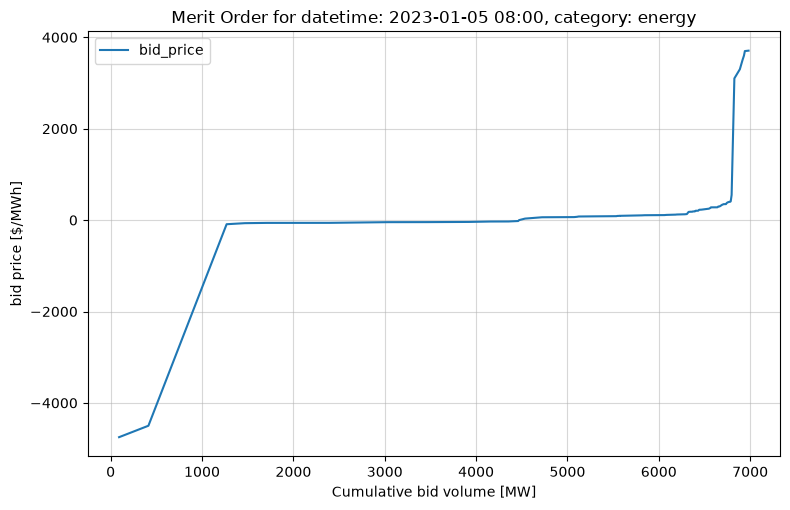

In [79]:
trading_period_of_interest_str = "2023-01-05 08:00"
trading_period_of_interest = pd.Timestamp(trading_period_of_interest_str)

merit_order_filtered = filter_merit_order(
    df = merit_order_cleansed,
    timestamp= trading_period_of_interest
)

merit_order_fig, ax = plot_merit_order(
period_data = merit_order_filtered,
timestamp=trading_period_of_interest)

plt.show()

[Findings]

- The curve has the same shape as the example. 
- Most of the capacity is offered below \$0: 4,461 MW out of 6,982 MW. The price only climbs steeply in the last few hundred MW.

[Further Analysis]

Now that we have merit_order_cleansed, we can have a quick look at the merit order across all periods: how much of the offered capacity is priced below \$0, and how much is left after meeting demand.

In [80]:
# Summarise the merit order to one row per trading period
merit_order_by_period = (
    merit_order_cleansed
    .groupby(level="datetime")
    .agg(
        demand=("demand", "first"),
        usep=("usep", "first"),
        offered_capacity=("bid_volume", "sum"),
    )
)

# Capacity offered below $0 in each period
merit_order_by_period["capacity_below_zero"] = (
    merit_order_cleansed[merit_order_cleansed["bid_price"] < 0]
    .groupby(level="datetime")["bid_volume"]
    .sum()
)

merit_order_by_period["share_below_zero"] = (
    merit_order_by_period["capacity_below_zero"]
    / merit_order_by_period["offered_capacity"]
)

# Spare capacity: the offered generation left over after meeting demand
merit_order_by_period["spare_capacity"] = (
    merit_order_by_period["offered_capacity"]
    - merit_order_by_period["demand"]
)

# 1. The merit order across all periods
display(
    merit_order_by_period
    .agg(["min", "median", "max"])
    .round(2)
)

# 2. Normal periods against the periods with an extreme USEP,
#    reusing the upper bound from the Layer 2 anomaly check
usep_upper_bound = (
    usep_validation["layer_2_anomaly"]["extreme_usep"]["upper_bound"].iloc[0]
)

merit_order_by_period["extreme_usep"] = (
    merit_order_by_period["usep"] > usep_upper_bound
)

display(
    merit_order_by_period
    .groupby("extreme_usep")
    .agg(
        periods=("usep", "size"),
        median_usep=("usep", "median"),
        median_spare_capacity=("spare_capacity", "median"),
        max_spare_capacity=("spare_capacity", "max"),
    )
    .round(1)
)

,demand,usep,offered_capacity,capacity_below_zero,share_below_zero,spare_capacity
min,4936.43,76.19,5837.1,4145.1,0.60,94.49
median,6019.68,177.09,6884.8,4537.1,0.67,844.20
max,7044.94,4500.00,7727.6,5468.1,0.75,1682.27


,periods,median_usep,median_spare_capacity,max_spare_capacity
extreme_usep,,,,
False,1452,166.6,850.1,1682.3
True,35,1078.1,254.7,420.3


[Findings]

- About two thirds of the offered capacity is priced below \$0 in every period, between 60% and 75%. This is the long flat part of the merit order curve.
- The spare capacity, which is the offered capacity left after meeting demand, is 844 MW in a typical period and as low as 94 MW.
- All 35 extreme USEPs were in periods with 420 MW of spare capacity or less, with a median of 255 MW against 850 MW for the other periods.

# Task 3

**Summary**

We wrote `calculate_clearing_price()`, which takes the offer stack of 1 trading period and the demand, and returns the estimated clearing price.

- **Logic:** find the first tranche where `cumulative_bid_volume` is greater than or equal to the demand. This is the marginal generator, and its `bid_price` is the clearing price.
- **Like for like plot:** the merit order from Task 2, with the demand, the estimated clearing price and the actual USEP marked on the curve.
- **Comparison:** run the function on all 1,487 periods and compare the estimate against the actual USEP.


**Findings and Insights**

- For 2023-01-05 08:00, demand is 6,513.65 MW. The estimated clearing price is \$250.00/MWh and the actual USEP is \$280.41/MWh.
- The actual USEP is higher than the estimate in every period, so the difference is systematic, not random.
- The estimate is close for a typical period, with a median difference of \$7.66/MWh.
- The mean difference is higher at \$27.40/MWh. It is skewed by 5 periods on 9 Jan and 17 Jan, where USEP is more than \$2,500 above the estimate. Without them the mean is \$17.38/MWh.
- The difference is likely caused by transmission losses and unit constraints, which the simplified merit order doesn't capture.

**Deliverable**

- `calculate_clearing_price()`, also in `src/market_clearing_calculation.py` for the unit test.
- The like for like merit order plot for 2023-01-05 08:00.
- `price_comparison`, the estimate against the actual USEP for every period.
- **Unit test (bonus):** 7 pytest cases in `tests/test_clearing_price_calc.py`, all passing.


[Analysis] Edge case: demand <=0

Demand must be positive for this simplified merit-order model.

Negative demand is inconsistent with the interpretation of system demand, while zero demand means no marginal generator is required, so a meaningful clearing price cannot be determined.

In [81]:
def calculate_clearing_price(
    period_data: pd.DataFrame,
    demand: float,
) -> float:
    """
    Return the marginal bid price required to meet demand
    for a single trading period.

    period_data must contain:
        - cumulative_bid_volume
        - bid_price
    """

    # Prevent empty input df
    if period_data.empty:
        raise ValueError("Offer stack is empty.")
    # Prevent invalid demand
    if demand <= 0:
        raise ValueError("Demand must be greater than zero.")
    # prevent 
    if not period_data[
        "cumulative_bid_volume"
    ].is_monotonic_increasing:
        raise ValueError(
            "Cumulative bid volume must be increasing."
        )

    total_capacity = period_data[
        "cumulative_bid_volume"
    ].max()

    if demand > total_capacity:
        raise ValueError(
            f"Demand ({demand:.2f} MW) exceeds total offered "
            f"capacity ({total_capacity:.2f} MW)."
        )

    marginal_bid = period_data.loc[
        period_data["cumulative_bid_volume"] >= demand
    ].iloc[0]

    return float(marginal_bid["bid_price"])

In [82]:
demand_values = (
    merit_order_filtered["demand"]
    .dropna()
    .unique()
)

if len(demand_values) != 1:
    raise ValueError(
        "Expected exactly one demand value "
        "for the selected trading period."
    )

demand = float(demand_values[0])

estimated_clearing_price = calculate_clearing_price(
    period_data=merit_order_filtered,
    demand=demand,
)

print(f"Demand: {demand:,.2f} MW")
print(
    f"Estimated clearing price: "
    f"${estimated_clearing_price:,.2f}/MWh"
)

Demand: 6,513.65 MW
Estimated clearing price: $250.00/MWh


[Action]

Now adding the estimated clearing price and the actual USEP back to the plot

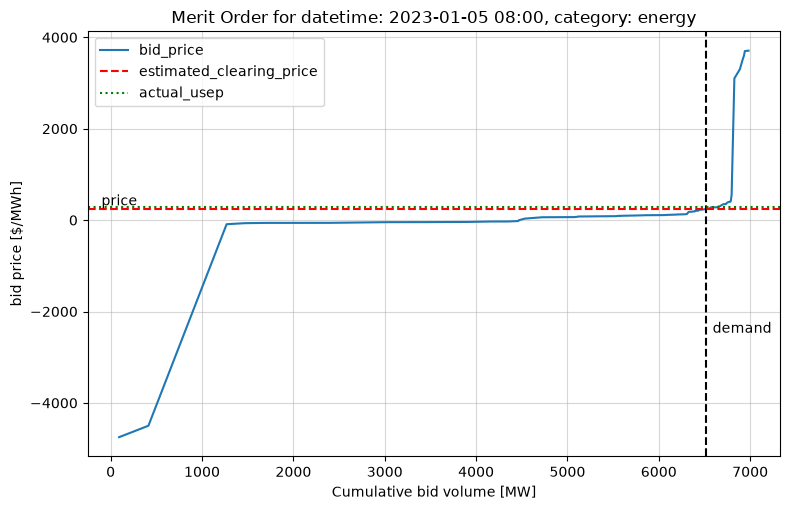

In [83]:
# Calculate the clearing price for the selected trading period.
demand = float(
    merit_order_filtered["demand"]
    .dropna()
    .unique()[0]
)

actual_usep = float(
    merit_order_filtered["usep"]
    .dropna()
    .unique()[0]
)

estimated_clearing_price = calculate_clearing_price(
    period_data=merit_order_filtered,
    demand=demand,
)


# Add market-clearing references to the existing merit-order figure.
ax.axvline(
    demand,
    color="black",
    linestyle="--",
)

ax.axhline(
    estimated_clearing_price,
    color="red",
    linestyle="--",
    label="estimated_clearing_price",
)

ax.axhline(
    actual_usep,
    color="green",
    linestyle=":",
    label="actual_usep",
)


# Add labels directly to the plot, matching the supplied example.
x_min, x_max = ax.get_xlim()
y_min, y_max = ax.get_ylim()

ax.text(
    x_min + 0.02 * (x_max - x_min),
    estimated_clearing_price,
    "price",
    ha="left",
    va="bottom",
)

ax.text(
    demand + 0.01 * (x_max - x_min),
    y_min + 0.30 * (y_max - y_min),
    "demand",
    ha="left",
    va="center",
)


# Keep the original merit-order title.
ax.set_title(
    f"Merit Order for datetime: "
    f"{trading_period_of_interest:%Y-%m-%d %H:%M}, "
    f"category: energy"
)

# Legend now shows bid_price, estimated clearing price and actual USEP.
ax.legend()

merit_order_fig.tight_layout()

display(merit_order_fig)

[Further Analysis]

Visually, the actual USEP seem to be close to the estimated clearing price. However, when we examinate the actual, we found that USEP doesn't equal to the estimated price. 

In [84]:
def find_actual_usep(
    period_data: pd.DataFrame,
) -> float:
    """
    Return the published USEP for a single trading period.
    """
    usep_values = (
        period_data["usep"]
        .dropna()
        .unique()
    )

    if len(usep_values) != 1:
        raise ValueError(
            "Expected exactly one USEP value "
            "for the selected trading period."
        )

    return float(usep_values[0])

In [85]:
actual_usep = find_actual_usep(
    period_data=merit_order_filtered,
)

print(f"Demand: {demand:,.2f} MW")
print(
    f"Estimated clearing price: "
    f"${estimated_clearing_price:,.2f}/MWh"
)
print(
    f"Actual USEP: "
    f"${actual_usep:,.2f}/MWh"
)


Demand: 6,513.65 MW
Estimated clearing price: $250.00/MWh
Actual USEP: $280.41/MWh


Actual USEP is $30.41 higher than the Estimated clearing price. 

Going one step further, we can compare all the USEP and clearing price to find some pattern. 

In [86]:
def compare_clearing_prices(
    df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Compare estimated clearing price against actual USEP
    for each trading period.

    price_difference = actual USEP - estimated clearing price
    """
    results = []

    for timestamp, period_data in df.groupby(level="datetime"):
        demand_values = (
            period_data["demand"]
            .dropna()
            .unique()
        )

        usep_values = (
            period_data["usep"]
            .dropna()
            .unique()
        )

        # Skip periods without complete demand / USEP data.
        if len(demand_values) != 1 or len(usep_values) != 1:
            continue

        demand = float(demand_values[0])
        actual_usep = float(usep_values[0])

        estimated_price = calculate_clearing_price(
            period_data=period_data,
            demand=demand,
        )

        difference = actual_usep - estimated_price

        results.append(
            {
                "datetime": timestamp,
                "demand": demand,
                "estimated_clearing_price": estimated_price,
                "actual_usep": actual_usep,
                "price_difference": difference,
                "absolute_difference": abs(difference),
            }
        )

    return (
        pd.DataFrame(results)
        .set_index("datetime")
        .sort_index()
    )

In [87]:
price_comparison = compare_clearing_prices(
    merit_order_cleansed
)

display(price_comparison.head())

,demand,estimated_clearing_price,actual_usep,price_difference,absolute_difference
datetime,,,,,
2023-01-01 00:00:00,5539.761,155.57,158.62,3.05,3.05
2023-01-01 00:30:00,5443.353,129.20,147.58,18.38,18.38
2023-01-01 01:00:00,5384.523,121.70,126.83,5.13,5.13
2023-01-01 01:30:00,5367.272,125.77,144.53,18.76,18.76
2023-01-01 02:00:00,5331.369,125.77,144.51,18.74,18.74


In [88]:
print(
    f"Mean difference (USEP - estimated): "
    f"${price_comparison['price_difference'].mean():,.2f}/MWh"
)

print(
    f"Median difference (USEP - estimated): "
    f"${price_comparison['price_difference'].median():,.2f}/MWh"
)

print(
    f"Mean absolute difference: "
    f"${price_comparison['absolute_difference'].mean():,.2f}/MWh"
)

print(
    f"Actual USEP higher than estimate: "
    f"{(price_comparison['price_difference'] > 0).mean():.1%}"
)

print(
    f"Actual USEP lower than estimate: "
    f"{(price_comparison['price_difference'] < 0).mean():.1%}"
)

Mean difference (USEP - estimated): $27.40/MWh
Median difference (USEP - estimated): $7.66/MWh
Mean absolute difference: $27.40/MWh
Actual USEP higher than estimate: 100.0%
Actual USEP lower than estimate: 0.0%


[Analysis]

As we can see here January 2023 trading periods, the published USEP was consistently higher than the clearing price estimated using the simplified merit-order approach.

The median difference was $7.66/MWh, indicating that the estimate was relatively close for a typical period. 

However, the mean difference was higher at $27.40/MWh, suggesting that a smaller number of periods with larger price differences skew the distribution upward. 

As USEP is consistently above the estimate, the difference appears systematic rather than randomly distributed around zero. 

This indicates that the simplified merit-order calculation captures the general marginal-pricing relationship but does not reproduce all factors incorporated into the published USEP.

[Conclusion]

By doing further research, the difference is likely to be caused by:

1. Transmission losses. The demand value only captures the load, however the generator will have to produce enough to cover demand + transmission loss, which pushes the clearing point further up the stack. 
2. Unit constraints: in real dispatch some cheap capacity from generator units can't be used during certain trading periods due to constraints like ramp limits, minimum stable generation. This reduced the available bid volume. 



[Bonus]

the pytest file located in /tests/test_clearing_calculation.py

This will be a data driven unit test with a manually created dateset, and rules for expected output from this dataset, to testing the function in different scenarios:

- Clearing price within a tranche

Verifies that when demand falls between two cumulative bid-volume levels, the function selects the first offer tranche that provides enough cumulative capacity to meet demand. This is the core market-clearing behaviour.

- Clearing price on an exact boundary

Checks that when demand exactly equals a cumulative bid-volume level, the price of that exact tranche is returned. This confirms the >= demand logic is correct.

- Demand above total offered capacity

Confirms that the function raises an error when demand cannot be satisfied by the available generation offers, rather than extrapolating beyond the supplied data.

- Non-positive demand

Checks that zero or negative demand is rejected because the clearing-price calculation assumes a positive level of demand that must be met by generation.

- Empty offer stack

Verifies that the function raises an error when no offer data is available, because a clearing price cannot be calculated without a supply stack.

- Non-monotonic cumulative bid volume

Checks that the function rejects incorrectly ordered or invalid cumulative-volume data. The calculation assumes cumulative bid volume increases as the offer stack progresses.


The test can be trigger to run using uv



In [89]:
NOTEBOOK_DIR = Path.cwd()
%cd {PROJECT_ROOT}
!uv run pytest -v
%cd {NOTEBOOK_DIR}

c:\Users\Steve Zhang\Documents\GitHub\flo-energy-data-analytics
============================= test session starts =============================
platform win32 -- Python 3.12.7, pytest-9.1.1, pluggy-1.6.0 -- C:\Users\Steve Zhang\Documents\GitHub\flo-energy-data-analytics\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: c:\Users\Steve Zhang\Documents\GitHub\flo-energy-data-analytics
configfile: pyproject.toml
plugins: platformdirs-4.12.2
collecting ... collected 7 items

tests/test_clearing_price_calc.py::test_clearing_price_within_tranche PASSED [ 14%]
tests/test_clearing_price_calc.py::test_clearing_price_on_exact_boundary PASSED [ 28%]
tests/test_clearing_price_calc.py::test_demand_above_total_capacity_raises PASSED [ 42%]
tests/test_clearing_price_calc.py::test_non_positive_demand_raises[0.0] PASSED [ 57%]
tests/test_clearing_price_calc.py::test_non_positive_demand_raises[-100.0] PASSED [ 71%]
tests/test_clearing_price_calc.py::test_empty_offer_stack_raises PASSED  [ 85%]
te

**EOF**